# Test Chebyshev_pytorch.py implementation
This module provide basic functionality with the Chebyshev basis, useful for non-periodic functions defined on $[-1,1]$. In particular we implement the possibilities of:
- create a 1D or 2D Chebyshev grid, second type grid (extrema points);
- perform classical Chebyshev fast transform;
- perform classical Chebyshev fast anti-transform;
- compute differentiation in the Chebyshev space;
- compute integration in the Chebyshev space.

Useful importation.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import chebyshev_utilities as cheb

Set default type as `float64` and the default device as `cpu`. I use this settings only in testing and not in production.
- `float64` is slower but more accurate, I need it to check if the implementation is correct.
- `cpu` is slower than `gpu` device but is easier use the cpu device to communicate with other libraries for the testing example.

In [2]:
mydevice = torch.device('cpu') # force to use cpu to simplify testing
torch.set_default_device(mydevice) # default tensor device
torch.set_default_dtype(torch.float64) # default tensor dtype for test purposes

### Test 1
Test della griglia di Chebyshev in 1D. We implement the grid that includes the extrema points, we make this choice because this grid include the boundary values.

Chebyshev's grid:  tensor([-1.0000, -0.9864, -0.9458, -0.8795, -0.7891, -0.6773, -0.5469, -0.4017,
        -0.2455, -0.0826,  0.0826,  0.2455,  0.4017,  0.5469,  0.6773,  0.7891,
         0.8795,  0.9458,  0.9864,  1.0000])


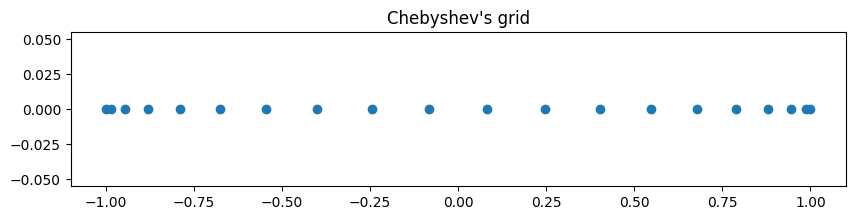

In [3]:
# Calculate Chebyshev's grid in 1D
n = 20
grid = cheb.Chebyshev_grid_1d(n)
print("Chebyshev's grid: ", grid)

# Plot Chebyshev's grid in 1D
plt.figure(figsize=(10, 2))
plt.plot(grid, np.zeros(n), 'o')
plt.title("Chebyshev's grid")
plt.show()

### Test 2
Test della griglia di Chebyshev in 2D, for multi-dimensional cases the grid is obtained with the tensor porduct of grid in 1D case.

grid 2D shape:  torch.Size([7, 8, 2])
Chebyshev's grid 2D:  tensor([[-1.0000e+00, -1.0000e+00, -1.0000e+00, -1.0000e+00, -1.0000e+00,
         -1.0000e+00, -1.0000e+00, -1.0000e+00],
        [-8.6603e-01, -8.6603e-01, -8.6603e-01, -8.6603e-01, -8.6603e-01,
         -8.6603e-01, -8.6603e-01, -8.6603e-01],
        [-5.0000e-01, -5.0000e-01, -5.0000e-01, -5.0000e-01, -5.0000e-01,
         -5.0000e-01, -5.0000e-01, -5.0000e-01],
        [-6.1232e-17, -6.1232e-17, -6.1232e-17, -6.1232e-17, -6.1232e-17,
         -6.1232e-17, -6.1232e-17, -6.1232e-17],
        [ 5.0000e-01,  5.0000e-01,  5.0000e-01,  5.0000e-01,  5.0000e-01,
          5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 8.6603e-01,  8.6603e-01,  8.6603e-01,  8.6603e-01,  8.6603e-01,
          8.6603e-01,  8.6603e-01,  8.6603e-01],
        [ 1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00,
          1.0000e+00,  1.0000e+00,  1.0000e+00]]) 
 tensor([[-1.0000, -0.9010, -0.6235, -0.2225,  0.2225,  0.6235,  0.9010,  1.0

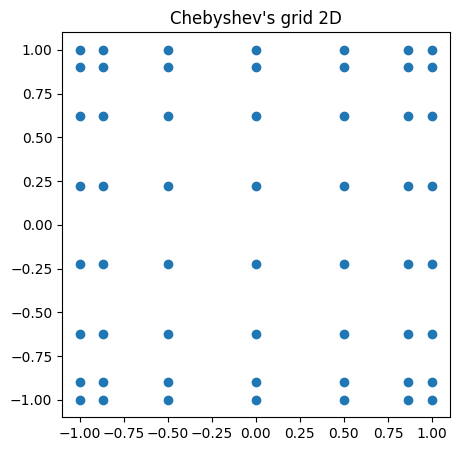

In [4]:
# Compute and calculate Chebyshev's grid in 2D
n = [7, 8]

# PATCH 1
a = [-1.0, -1.0]
b = [1.0, 1.0]

grid = cheb.Chebyshev_grid_2d(n, a, b)
print("grid 2D shape: ", grid.shape)
x, y = grid[:, :, 0], grid[:, :, 1]
print("Chebyshev's grid 2D: ", x, "\n", y)

plt.figure(figsize=(5, 5))
plt.plot(torch.reshape(x, (-1, 1)), torch.reshape(y, (-1, 1)), 'o')
plt.title("Chebyshev's grid 2D")
plt.show()

### Test 3.1
Check if our implementation of the Chebyshev transform is correct. To do it we use the numpy library that have some routines that works with the Chebyshev polynomials and Chebyshev coefficients.

In [5]:
n = 50 # number of coefficients
coeff = torch.randn((n,))*4 # random coefficients
T = np.polynomial.chebyshev.Chebyshev(np.asarray(coeff)) # Chebyshev polynomial
values = torch.tensor( T(np.asarray(cheb.Chebyshev_grid_1d(n + 10))).reshape(-1, 1) ) # values of the polynomial in the Chebyshev grid

num_coeff = cheb.values_to_coefficients(values).reshape(-1, )
print("Shape of the pointwise evaluation: ", num_coeff.shape)

error1 = torch.norm(coeff - num_coeff[:n], float('inf'))
error2 = torch.norm(num_coeff[n:], float('inf'))
print(f"Test Chebyshev transform: {error1 + error2}")

Shape of the pointwise evaluation:  torch.Size([60])
Test Chebyshev transform: 5.724987339185723e-14


### Test 3.2
Check our implementation of Chebyshev transform in 2D case.

In [18]:
n = 10 # number of coefficients
c = torch.randn((n, n)) # random coefficients
grid = cheb.Chebyshev_grid_2d(n, [-1.0, -1.0], [1.0, 1.0])
X, Y = grid[:, :, 0], grid[:, :, 1]

print("Shape of the 2D grid: ", X.shape, Y.shape)
values = torch.tensor(np.polynomial.chebyshev.chebval2d(X, Y, np.asarray(c))) # Evaluated Chebyshev polynomial
print("Shape of the pointwise evaluation: ", values.shape)

appro_values = cheb.coefficients_to_values( c.unsqueeze(-1) ).squeeze(-1)
print("Shape of the calculated coefficients: ", appro_values.shape)

error = torch.norm(values - appro_values, float('inf'))
print(f"Test Chebyshev transform 2D: {error}")

Shape of the 2D grid:  torch.Size([10, 10]) torch.Size([10, 10])
Shape of the pointwise evaluation:  torch.Size([10, 10])
Shape of the calculated coefficients:  torch.Size([10, 10])
Test Chebyshev transform 2D: 2.1316282072803006e-14


### Test 3.3
Check out implementation of batched-Chebyshev anti-transform.

In [19]:
n_batch = 6
n_patch = 4
d_v = 4
n = 20

c = torch.randn((n_batch, n_patch, n, n, d_v)) # random coefficients
grid = cheb.Chebyshev_grid_2d(n, [-1.0, -1.0], [1.0, 1.0])
X, Y = grid[:, :, 0], grid[:, :, 1]

values = torch.ones_like(c)
for batch_idx in range(n_batch):
    for patch_idx in range(n_patch):
        for v in range(d_v):
            values[batch_idx, patch_idx, :, :, v] = torch.tensor(np.polynomial.chebyshev.chebval2d(X, Y, np.asarray(c[batch_idx, patch_idx, :, :, v])) )

appro_values = cheb.patched_coefficients_to_values(c)
error = torch.norm(values - appro_values, float('inf'))
print(f"Test Chebyshev transform 2D with batch: {error}")

Test Chebyshev transform 2D with batch: 2.0961010704922955e-13


### Test 4.1
Check if our implementation of the Chebyshev anti-transform is correct. To do it we start with random values (that can represents both the pointwise evaluation or some random coefficients respect to the Chebyshev basis) and perform the Chebyshev transform and anti-trasform (and viceversa) and compare the outputs obtained with the initail values.

In [8]:
x = torch.randn((4, 3, 2, 2))*4 # random values
error1 = torch.norm((x - cheb.values_to_coefficients(cheb.coefficients_to_values(x))).reshape(-1, ), float('inf')) # error in the values
error2 = torch.norm((x - cheb.coefficients_to_values(cheb.values_to_coefficients(x))).reshape(-1, ), float('inf')) # error in the coefficients
print(f"Test antitransform + transform: {error1}")
print(f"Test transform + antitransform: {error2}")

Test antitransform + transform: 1.7763568394002505e-15
Test transform + antitransform: 8.881784197001252e-16


### Test 4.2
Check our implementation of Chebyshev anti-transform in 2D case.

In [ ]:
n = 5 # number of coefficients
c = torch.randn((n, n))*4 # random coefficients
grid = cheb.Chebyshev_grid_2d(n, [-1.0, -1.0], [1.0, 1.0])
X, Y = grid[:, :, 0], grid[:, :, 1]
# print(X)
# print(Y)

# plot the grid
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# plt.imshow(X)
# plt.colorbar()
# plt.title("X grid")
# plt.subplot(1, 2, 2)
# plt.imshow(Y)
# plt.colorbar()
# plt.title("Y grid")
# plt.show()

print("Shape of the 2D grid: ", X.shape, Y.shape)
values = torch.tensor(np.polynomial.chebyshev.chebval2d(X, Y, np.asarray(c))) # Evaluated Chebyshev polynomial
print("Shape of the pointwise evaluation: ", values.shape)

appro_coeffs = cheb.values_to_coefficients( values.unsqueeze(-1) ).squeeze(-1)
print("Shape of the calculated coefficients: ", appro_coeffs.shape)

error = torch.norm(c - appro_coeffs[:n, :n], float('inf'))
print(f"Test Chebyshev transform 2D: {error}")


Shape of the 2D grid:  torch.Size([5, 5]) torch.Size([5, 5])
Shape of the pointwise evaluation:  torch.Size([5, 5])
Shape of the calculated coefficients:  torch.Size([5, 5])
Test Chebyshev transform 2D: 2.886579864025407e-15


### Test 4.3
Check out implementation of batched-Chebyshev transform.

In [10]:
n_batch = 6
n_patch = 4
d_v = 4
n = 20

c = torch.randn((n_batch, n_patch, n, n, d_v)) # random coefficients
grid = cheb.Chebyshev_grid_2d(n, [-1.0, -1.0], [1.0, 1.0])
X, Y = grid[:, :, 0], grid[:, :, 1]

values = torch.ones_like(c)
for batch_idx in range(n_batch):
    for patch_idx in range(n_patch):
        for v in range(d_v):
            values[batch_idx, patch_idx, :, :, v] = torch.tensor(np.polynomial.chebyshev.chebval2d(X, Y, c[batch_idx, patch_idx, :, :, v]) )

appro_coeffs = cheb.patched_values_to_coefficients(values)
error = torch.norm(c - appro_coeffs, float('inf'))
print(f"Test Chebyshev transform 2D with batch: {error}")

Test Chebyshev transform 2D with batch: 1.2212453270876722e-14


### Test 5
Check if our implementation of the differentiation in the Chebyshev space is correct. To do this we calculate the coefficients of the derivatives in Chebyshev space both with our implementation and with the numpy's routine and check the error.

In [11]:
n = 50
k = 4
for i in range(k):
    coeff = torch.randn((n, ))*4 # random coefficients
    T = np.polynomial.chebyshev.Chebyshev(np.asarray(coeff)) # Chebyshev polynomial
    if i == 0:
        values = torch.tensor(T( np.asarray(cheb.Chebyshev_grid_1d(n)) ).reshape(-1, 1)) # values of the polynomial in the Chebyshev grid
        coeff_diff = torch.tensor(T.deriv().coef.reshape(-1, 1)) # values of the derivative of the polynomial in the Chebyshev grid
    else:
        values = torch.cat((values, torch.tensor(T( np.asarray(cheb.Chebyshev_grid_1d(n)) ).reshape(-1, 1))), dim=1) # values of the polynomial in the Chebyshev grid
        coeff_diff = torch.cat((coeff_diff, torch.tensor(T.deriv().coef).reshape(-1, 1)), dim=1)
print("Shape of the pointwise evaluation: ", values.shape)
print("Shape of the coefficients of the derivative: ", coeff_diff.shape)

# Coefficients of the polynomial with our Chebyshev transform
num_coeff = cheb.values_to_coefficients(values) 
coeff_diff_appro = cheb.differentiate(num_coeff, 0)
print("Shape of the function coefficients:", num_coeff.shape)
print("Shape of the coefficients of the derivative:", coeff_diff_appro.shape)

# Test differentiation
error = torch.norm(coeff_diff_appro[:-1] - coeff_diff, float('inf')) 
print("Test differentiation: ", error.item())

Shape of the pointwise evaluation:  torch.Size([50, 4])
Shape of the coefficients of the derivative:  torch.Size([49, 4])
Shape of the function coefficients: torch.Size([50, 4])
Shape of the coefficients of the derivative: torch.Size([50, 4])
Test differentiation:  1.1141310096718371e-11


### Test 6
Check if torch.vmap is correct to calculate the differentiation in more than 1D. We calculate the differentiation in 2D in two ways, more manually with the function `cheb.differentiate_2d_x` e `cheb.differentiate_2d_y` and with the more general `cheb.differentiate` and we check that are equal.

In [12]:
n = 50
coeff = torch.randn((n, n, n))*4
values = np.polynomial.chebyshev.chebgrid3d(np.asarray(cheb.Chebyshev_grid_1d(n+10)), 
                                np.asarray(cheb.Chebyshev_grid_1d(n+10)), 
                                np.asarray(cheb.Chebyshev_grid_1d(n+10)), 
                                np.asarray(coeff))
num_coeff = cheb.values_to_coefficients(torch.tensor(values))
print("Shape of the pointwise evaluation: ", values.shape)
print("Shape of the coefficients: ", num_coeff.shape)

## Calculation with the function cheb.differentiate
diff_coeff_dx= cheb.differentiate(num_coeff, 0)
print("Shape of the coefficients of the derivative dx: ", diff_coeff_dx.shape)
diff_coeff_dy= cheb.differentiate(num_coeff, 1)
print("Shape of the coefficients of the derivative dy: ", diff_coeff_dy.shape)

## Calculation with the function cheb.differentiate_2dx and cheb.differentiate_2dy
diff_coeff_dx_2 = cheb.differentiate_2dx(num_coeff, 0)
print("Shape of the coefficients of the derivative dx_2: ", diff_coeff_dx_2.shape)
diff_coeff_dy_2 = cheb.differentiate_2dy(num_coeff, 0)
print("Shape of the coefficients of the derivative dy_2: ", diff_coeff_dy_2.shape)

error_dx = torch.norm(diff_coeff_dx - diff_coeff_dx_2,  float('inf'))
error_dy = torch.norm(diff_coeff_dy - diff_coeff_dy_2,  float('inf'))
print("Test 2d differentiation dx: ", error_dx.item()) # my and native implementation are equivalent
print("Test 2d differentiation dy: ", error_dy.item()) # my and native implementation are equivalent

Shape of the pointwise evaluation:  (60, 60, 60)
Shape of the coefficients:  torch.Size([60, 60, 60])
Shape of the coefficients of the derivative dx:  torch.Size([60, 60, 60])
Shape of the coefficients of the derivative dy:  torch.Size([60, 60, 60])
Shape of the coefficients of the derivative dx_2:  torch.Size([60, 60, 60])
Shape of the coefficients of the derivative dy_2:  torch.Size([60, 60, 60])
Test 2d differentiation dx:  0.0
Test 2d differentiation dy:  0.0


### Test 7
Check if our implementation of the integration in the Chebyshev space is correct. To do this we calculate the coefficients of the derivatives in Chebyshev space both with our implementation and with the numpy's routine and check the error.

In [13]:
n = 50
coeff = torch.randn((n, ))*4 # random coefficients
T = np.polynomial.chebyshev.Chebyshev(np.asarray(coeff)) # Chebyshev polynomial
values = T(np.asarray(cheb.Chebyshev_grid_1d(n))).reshape(-1, 1) # values of the polynomial in the Chebyshev grid

# Coefficients of the polynomial with out Chebyshev transform
num_coeff = cheb.values_to_coefficients(torch.tensor(values))

# Test integration
error = torch.norm( cheb.integrate(num_coeff, 0).reshape(-1,)[1:(n+1)] - torch.tensor(T.integ().coef)[1:],  float('inf') )
print("Test integration: ", error.item())

Test integration:  2.1316282072803006e-14


### Test 8
Check for the grid.

In [14]:
n = 5
x = cheb.Chebyshev_grid_1d(n)
y = cheb.Chebyshev_grid_1d(n)
X, Y = np.meshgrid(x, y, indexing="ij")
# print('X', X)
# print('Y', Y)
print("Shape of the 2D grid: ", X.shape, Y.shape)

grid = cheb.Chebyshev_grid_2d(n, [-1.0, -1.0], [1.0, 1.0])
print("grid 2D shape: ", grid.shape)
# print('gridx', grid[:, :, 0])
# print('gridy', grid[:, :, 1])

err = torch.norm(grid[:, :, 0] - X, float('inf')) + torch.norm(grid[:, :, 1] - Y, float('inf'))
print("Test err: ", err.item())


Shape of the 2D grid:  (5, 5) (5, 5)
grid 2D shape:  torch.Size([5, 5, 2])
Test err:  0.0


/tmp/ipykernel_3929625/1209685489.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err = torch.norm(grid[:, :, 0] - X, float('inf')) + torch.norm(grid[:, :, 1] - Y, float('inf'))


### Test 9
We check that our implementation of the boundary adapted basis is correct. In particular we create a random coefficients (that is the Chebyshev coefficients) and then construct and evaluate the polynomial on the grid, then we check that the corner values of the evaluated polynomial is equal to the coefficients of the basis $B_{0,0}, B_{0,1}, B_{1,0}, B_{1,1}$.

In [15]:
def get_M(n:int):
    """ 
    Function to get the matrix for the change of basis, B = M*T.
    n: int
        n is the dimension of the matrix.
    """
    M = torch.eye(n)
    M[0,0] = 1/2
    M[0, 1] = -1/2
    M[1, 0] = 1/2
    M[1, 1] = 1/2
    for i in range(2, n):
        if i % 2 == 0:
            M[i, 0] = -1
        else:
            M[i, 1] = -1
    return M

def get_M_1(n:int):
    """ 
    Function to get the inverse of the matrix for the change of basis, T = M_1*B.
    n: int
        n is the dimension of the matrix.
    """
    M_1 = torch.eye(n)
    M_1[0, 1] = 1
    M_1[1, 0] = -1
    for i in range(2, n):
        if i % 2 == 0:
            M_1[i, 0] = 1
            M_1[i, 1] = 1
        else:
            M_1[i, 0] = -1
            M_1[i, 1] = 1
    return M_1

In [16]:
n = 5 # number of coefficients

M = get_M(n)
M_1 = get_M_1(n)

c = torch.randn((n, n))*4 # random coefficients
x = cheb.Chebyshev_grid_1d(n + 10)
y = cheb.Chebyshev_grid_1d(n + 10)
X, Y = np.meshgrid(x, y, indexing="ij")

print("Shape of the 2D grid: ", X.shape, Y.shape)
values = torch.tensor(np.polynomial.chebyshev.chebval2d(X, Y, c)) # Evaluated Chebyshev polynomial
print("Shape of the pointwise evaluation: ", values.shape)

b = cheb.change_basis(c, M_1) # coefficients in the boundary adapted basis
print("Shape of the coefficients in the boundary adapted basis: ", b.shape)

error = max( list((b[0, 0] - values[0, 0], 
                     b[0, 1] - values[0, -1],
                     b[1, 0] - values[-1, 0],
                     b[1, 1] - values[-1, -1])))
print("error of the boundary adapted basis on the corners", error.item())

Shape of the 2D grid:  (15, 15) (15, 15)
Shape of the pointwise evaluation:  torch.Size([15, 15])
Shape of the coefficients in the boundary adapted basis:  torch.Size([5, 5])
error of the boundary adapted basis on the corners 1.2434497875801753e-14


Here I start from random values on a chebyshev grid, and approximate the cheb basis and then the boundary adapted basis and finally check the corners.

In [17]:
n = 5 # number of coefficients
M_1 = get_M_1(n)
values = torch.randn((n, n, 1))*4 # random coefficients
coeff = cheb.values_to_coefficients(values).squeeze(-1) # coefficients in the Chebyshev basis
coeff = cheb.change_basis(coeff, M_1) # coefficients in the boundary adapted basis
error = max( list((coeff[0, 0] - values[0, 0], 
                     coeff[0, 1] - values[0, -1],
                     coeff[1, 0] - values[-1, 0],
                     coeff[1, 1] - values[-1, -1])))
print("error of the boundary adapted basis on the corners", error)

error of the boundary adapted basis on the corners tensor([0.])
